# Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
np.set_printoptions(precision=2)

# Load Data

In [7]:
def load_house_data():
    data = np.loadtxt("./houses.txt", delimiter=',', skiprows=1)
    X = data[:, :4]
    y = data[:, 4]
    return X, y

X_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']

# Normalize training Data

In [8]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

Peak to Peak range by column in Raw        X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized X:[5.85 6.14 2.06 3.69]


# Create and fit the regression mdoel

In [26]:
s = SGDRegressor(max_iter=1000)
s.fit(X_norm, y_train)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

number of iterations completed: 128, number of weight updates: 12673.0


# Get Final Value of w and b

In [27]:
b_norm = s.intercept_
w_norm = s.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [109.81 -20.94 -32.31 -38.11], b:[363.15]


# Make predictions to see if model make predictions close to target

In [31]:
p1 = s.predict(X_norm)
p2 = np.dot(X_norm, w_norm)+b_norm
print(f"prediction using np.dot() and sgdr.predict match: {(p2 == p1).all()}")
print(f"Prediction on training set:\n{p2[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[295.19 485.77 389.59 491.93]
Target values 
[300.  509.8 394.  540. ]


# Prediction vs Traget Plot

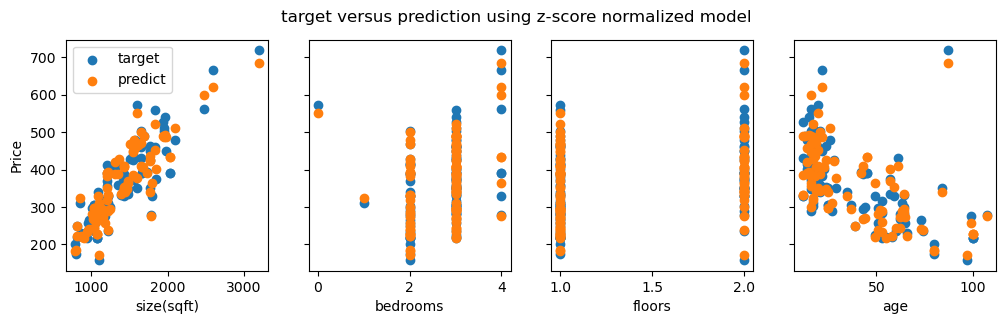

In [33]:
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],p1, label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()